In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv("metrices_df.csv")

In [ ]:
dataset = dataset[["Date",	"Open",	"High",	"Low"]]

In [ ]:
dataset["Date"] = pd.to_datetime(dataset["Date"])

In [ ]:
dataset.head()

,Date,Open,High,Low
0,2022-01-01,46197.31,47950.29,46196.03
1,2022-01-02,47737.35,47979.26,46666.18
2,2022-01-03,47306.41,47572.23,45707.55
3,2022-01-04,46450.79,47529.48,45587.91
4,2022-01-05,45824.54,47067.18,42510.86


In [ ]:
dataset.set_index("Date", inplace = True)

<Axes: xlabel='Date', ylabel='Open'>

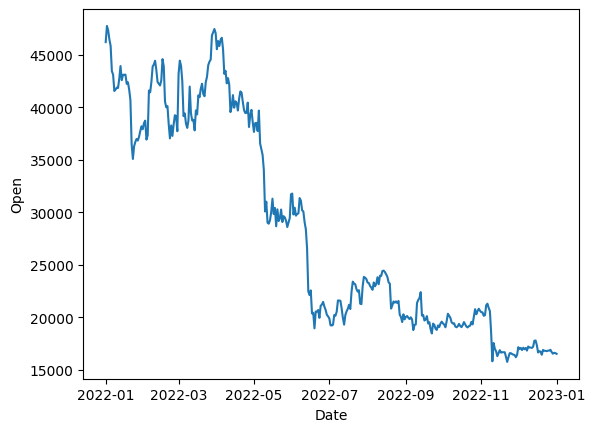

In [ ]:
sns.lineplot(x = "Date", y = "Open", data = dataset)

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
def test_stationarity(dataframe, var):
  dataframe["rollingmean"] = dataframe[var].rolling(window=12).mean()
  dataframe["rollingstd"] = dataframe[var].rolling(window=12).std()

  adftest = adfuller(dataframe[var])
  print("Test_Statistics", adftest[0])
  print("Criicality", adftest[4])

  sns.lineplot(x = "Date", y = dataframe.Open, data = dataframe)
  sns.lineplot(x = "Date", y = dataframe.rollingmean, data = dataframe)
  sns.lineplot(x = "Date", y = dataframe.rollingstd, data = dataframe)


Test_Statistics -1.420508893307151
Criicality {'1%': -3.4483935212959844, '5%': -2.8694912343676497, '10%': -2.571005879151811}


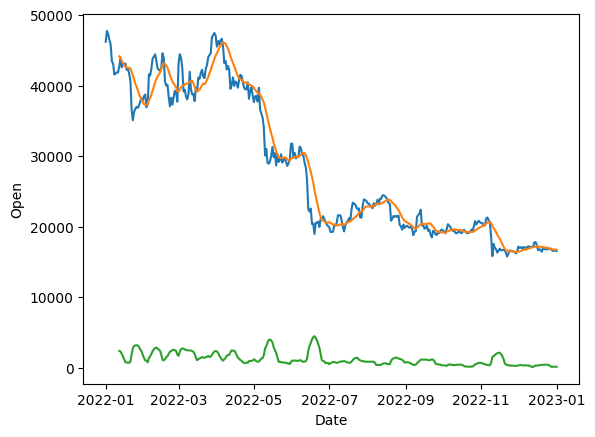

In [ ]:
test_stationarity(dataset, "Open")

In [ ]:
open_df = dataset[["Open","High", "Low"]]

In [ ]:
open_df.head()

,Open,High,Low
Date,,,
2022-01-01,46197.31,47950.29,46196.03
2022-01-02,47737.35,47979.26,46666.18
2022-01-03,47306.41,47572.23,45707.55
2022-01-04,46450.79,47529.48,45587.91
2022-01-05,45824.54,47067.18,42510.86


In [ ]:
open_df["Open"].shift()

,Open
Date,
2022-01-01,NaN
2022-01-02,46197.31
2022-01-03,47737.35
2022-01-04,47306.41
2022-01-05,46450.79
...,...
2022-12-28,16916.07
2022-12-29,16700.54
2022-12-30,16540.47


In [ ]:
open_df["Open_diff"] = open_df["Open"] - open_df["Open"].shift()

<ipython-input-14-eaf05cfe7a93>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  open_df["Open_diff"] = open_df["Open"] - open_df["Open"].shift()


In [ ]:
open_df.head()

,Open,High,Low,Open_diff
Date,,,,
2022-01-01,46197.31,47950.29,46196.03,NaN
2022-01-02,47737.35,47979.26,46666.18,1540.04
2022-01-03,47306.41,47572.23,45707.55,-430.94
2022-01-04,46450.79,47529.48,45587.91,-855.62
2022-01-05,45824.54,47067.18,42510.86,-626.25


<ipython-input-9-6eddec3e9dab>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe["rollingmean"] = dataframe[var].rolling(window=12).mean()
<ipython-input-9-6eddec3e9dab>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe["rollingstd"] = dataframe[var].rolling(window=12).std()


Test_Statistics -6.583638550542936
Criicality {'1%': -3.448905534655263, '5%': -2.8697161816205705, '10%': -2.5711258103550882}


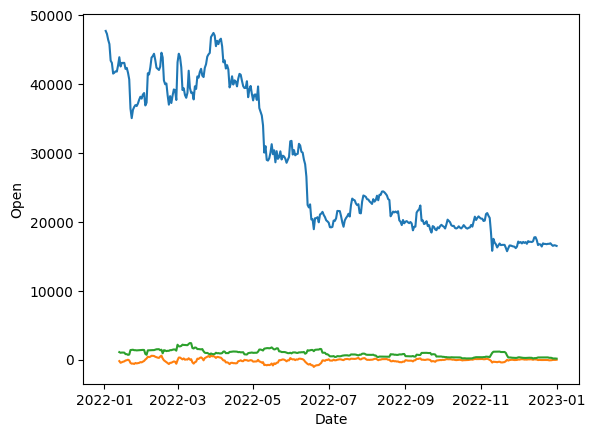

In [ ]:
test_stationarity(open_df.dropna(), "Open_diff")

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
#d = 1
#p = 9
#q = 9

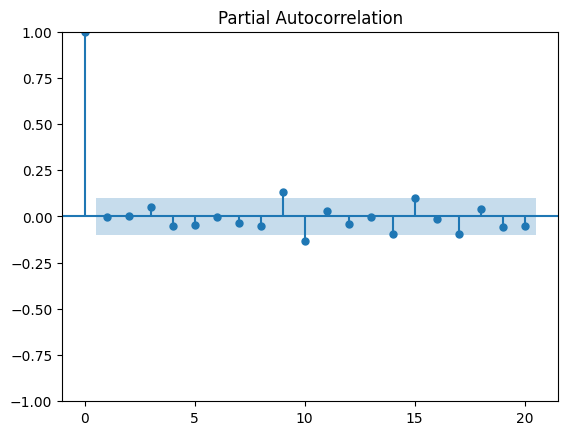

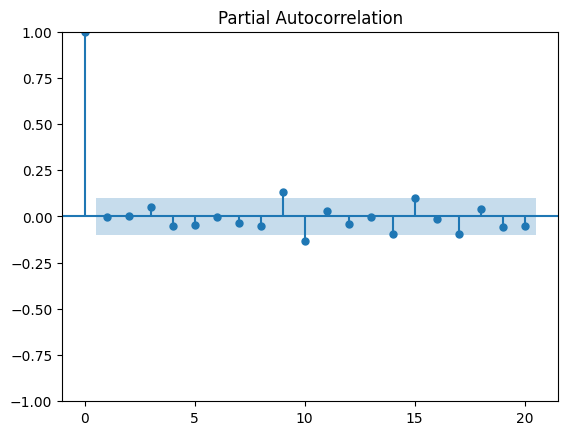

In [ ]:
plot_pacf(open_df["Open_diff"].dropna(), lags = 20)

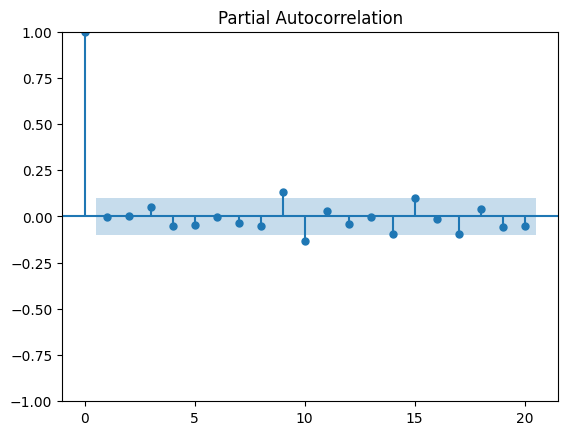

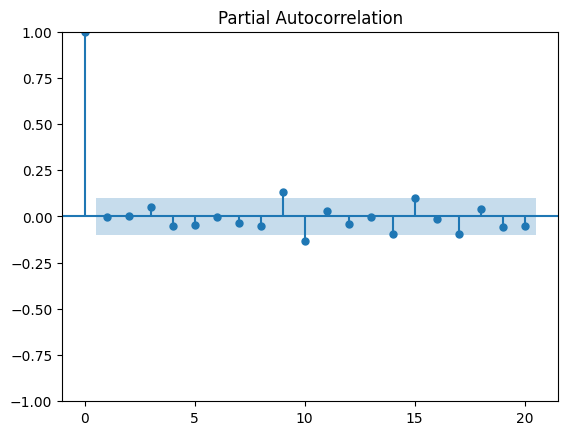

In [ ]:
plot_pacf(open_df["Open_diff"].dropna(), lags = 20)

In [ ]:
#d = 1
#p = 9
#q = 9

In [ ]:
round(len(open_df)*70/100)

256

In [ ]:
train = open_df[:256]
test = open_df[256:]

In [ ]:
model = ARIMA(train["Open"], order = (9,1,9))

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
model_fit = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
prediction = model_fit.predict(start = test.index[0], end = test.index[-1])

In [ ]:
open_df["ARIMA_Open_Pred"] = prediction

<Axes: xlabel='Date', ylabel='Open'>

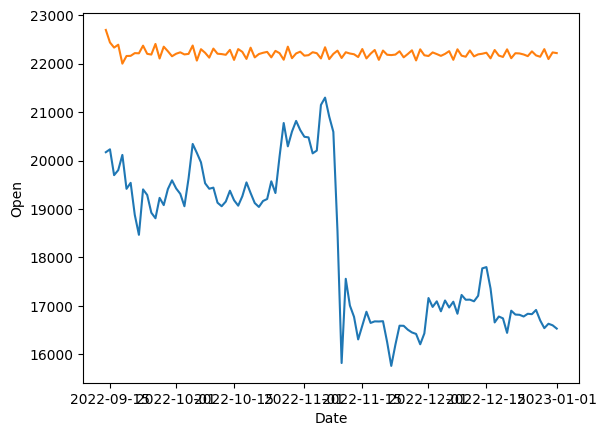

In [ ]:
sns.lineplot(x = "Date", y = "Open", data = open_df.dropna())
sns.lineplot(x = "Date", y = "ARIMA_Open_Pred", data = open_df.dropna())

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model1 = SARIMAX(open_df['Open'], order = (9,1,9), seasonal_order = (9,1,9,12))
model1_fit = model1.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [ ]:
SARI_pred = model1_fit.predict(start = test.index[0], end = test.index[-1])

In [ ]:
open_df["SARI_Open_Pred"] = SARI_pred

In [ ]:
sns.lineplot(x = "Date", y = "Open", data = open_df.dropna())
sns.lineplot(x = "Date", y = "SARI_Open_Pred", data = open_df.dropna())

In [62]:
open_df.index[-1]

Timestamp('2023-01-01 00:00:00')

In [63]:
future_df = pd.date_range(start = "2023-01-01", end = "2025-01-01")

In [66]:
model1_fit.predict(start = future_df[0], end = future_df[-1])

NameError: name 'model1_fit' is not defined